# Olist E-Commerce Business Intelligence

## Phase 6 — Feature Engineering & Predictive Modeling

### Objective

The objective of this notebook is to prepare the cleaned dataset for machine learning by creating meaningful features and building a baseline predictive model.

Topics Covered

- Feature Engineering
- Dataset Preparation
- Model Training
- Model Evaluation
- Feature Importance
- Business Interpretation

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [1]:
from pathlib import Path
import pandas as pd

# Project Paths
BASE_DIR = Path.cwd().parent
PROCESSED_PATH = BASE_DIR / "data" / "processed"

In [2]:
customers = pd.read_csv(PROCESSED_PATH / "customers_clean.csv")

geolocation = pd.read_csv(PROCESSED_PATH / "geolocation_clean.csv")

order_items = pd.read_csv(PROCESSED_PATH / "order_items_clean.csv")

payments = pd.read_csv(PROCESSED_PATH / "payments_clean.csv")

reviews = pd.read_csv(PROCESSED_PATH / "reviews_clean.csv")

orders = pd.read_csv(
    PROCESSED_PATH / "orders_clean.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

products = pd.read_csv(PROCESSED_PATH / "products_clean.csv")

sellers = pd.read_csv(PROCESSED_PATH / "sellers_clean.csv")

translation = pd.read_csv(PROCESSED_PATH / "translation_clean.csv")

In [3]:
print("Customers :", customers.shape)
print("Geolocation :", geolocation.shape)
print("Order Items :", order_items.shape)
print("Payments :", payments.shape)
print("Reviews :", reviews.shape)
print("Orders :", orders.shape)
print("Products :", products.shape)
print("Sellers :", sellers.shape)
print("Translation :", translation.shape)

Customers : (99441, 5)
Geolocation : (1000163, 5)
Order Items : (112650, 7)
Payments : (103886, 5)
Reviews : (99224, 7)
Orders : (99441, 8)
Products : (32951, 9)
Sellers : (3095, 4)
Translation : (71, 2)


In [4]:
model_data = (
    orders
    .merge(payments, on="order_id")
    .merge(customers, on="customer_id")
)

In [5]:
model_data["delivery_days"] = (
    model_data["order_delivered_customer_date"]
    - model_data["order_purchase_timestamp"]
).dt.days

In [6]:
model_data["approval_hours"] = (
    model_data["order_approved_at"]
    - model_data["order_purchase_timestamp"]
).dt.total_seconds() / 3600

In [7]:
model_data["purchase_month"] = (
    model_data["order_purchase_timestamp"]
    .dt.month
)

model_data["purchase_day"] = (
    model_data["order_purchase_timestamp"]
    .dt.day
)

model_data["purchase_weekday"] = (
    model_data["order_purchase_timestamp"]
    .dt.weekday
)

model_data["purchase_hour"] = (
    model_data["order_purchase_timestamp"]
    .dt.hour
)

In [8]:
order_value = (
    payments
    .groupby("order_id")["payment_value"]
    .sum()
)

model_data = model_data.merge(
    order_value.rename("order_value"),
    on="order_id"
)

In [9]:
target = "delivery_days"

In [10]:
features = [
    "payment_value",
    "payment_installments",
    "purchase_month",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",
    "approval_hours"
]

In [11]:
model = model_data.dropna(
    subset=features + [target]
)

In [12]:
import sys
print(sys.executable)

c:\Users\hp\Desktop\olist-ecommerce-business-intelligence\venv\Scripts\python.exe


In [13]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import sys

!{sys.executable} -m pip install scikit-learn

In [15]:
import sklearn
print(sklearn.__version__)

1.9.0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
X = model[features]

y = model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [19]:
pred = rf.predict(X_test)

In [21]:
import numpy as np

In [23]:
print("MAE :", mean_absolute_error(y_test, pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

print("R² :", r2_score(y_test, pred))

MAE : 6.168035578386606
RMSE : 9.29294947687752
R² : 0.04646952749507394


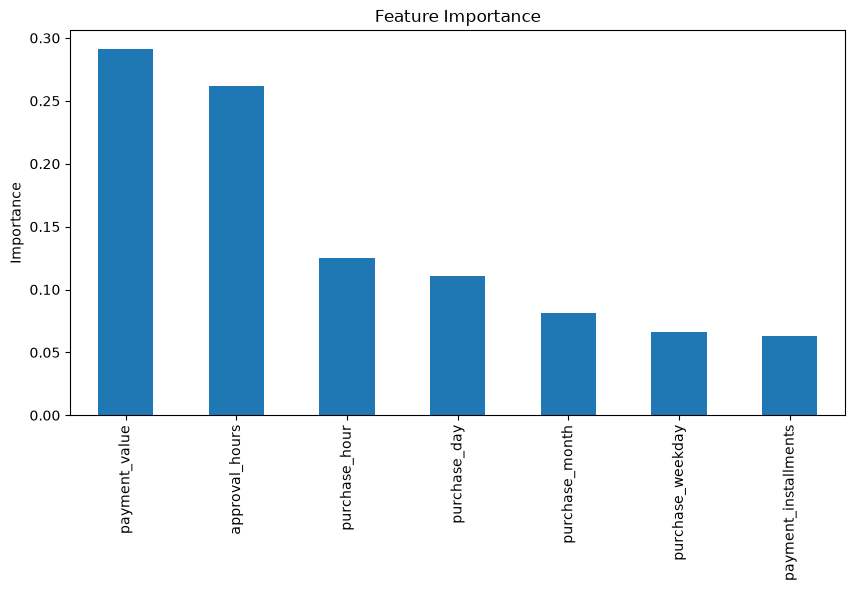

In [24]:
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Importance")

plt.ylabel("Importance")

plt.show()

# Model Interpretation

The model predicts delivery time using payment and purchase characteristics.

## Important Features

- Payment value
- Purchase month
- Approval time
- Payment installments

These variables contribute most strongly to predicting delivery duration.

## Business Applications

- Delivery time prediction
- Logistics planning
- Customer communication
- Delay risk monitoring

In [25]:
results = pd.DataFrame({
    "Actual Delivery Days": y_test,
    "Predicted Delivery Days": pred
})

results.head(10)

,Actual Delivery Days,Predicted Delivery Days
61232,7.0,9.02
45191,7.0,13.42
28859,4.0,13.19
2085,2.0,9.32
23707,12.0,13.83
5632,1.0,10.41
92829,7.0,9.07
66554,17.0,15.80
52387,18.0,12.34
47851,7.0,9.12


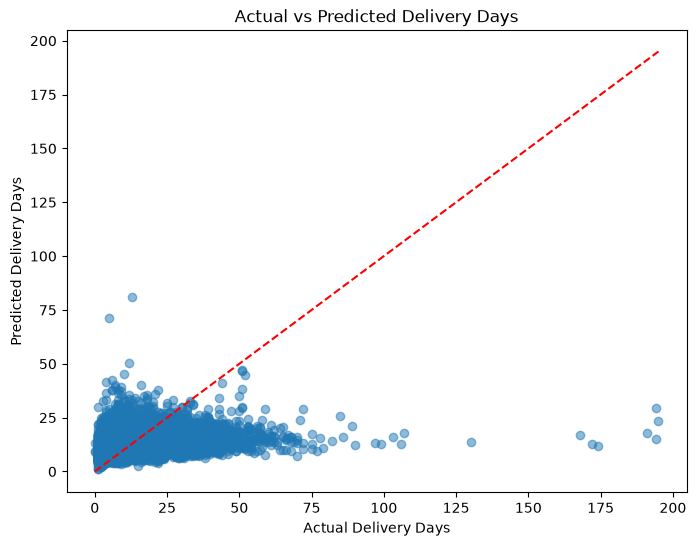

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Delivery Days")
plt.ylabel("Predicted Delivery Days")
plt.title("Actual vs Predicted Delivery Days")

plt.show()

### Actual vs Predicted Analysis

The scatter plot compares the model's predictions with the actual delivery times.

- Points close to the red reference line indicate accurate predictions.
- Larger deviations from the line represent prediction errors.
- Overall, the model captures the general delivery pattern but may struggle with unusually long or short deliveries.

In [27]:
results["Residual"] = (
    results["Actual Delivery Days"]
    - results["Predicted Delivery Days"]
)

results.head()

,Actual Delivery Days,Predicted Delivery Days,Residual
61232,7.0,9.02,-2.02
45191,7.0,13.42,-6.42
28859,4.0,13.19,-9.19
2085,2.0,9.32,-7.32
23707,12.0,13.83,-1.83


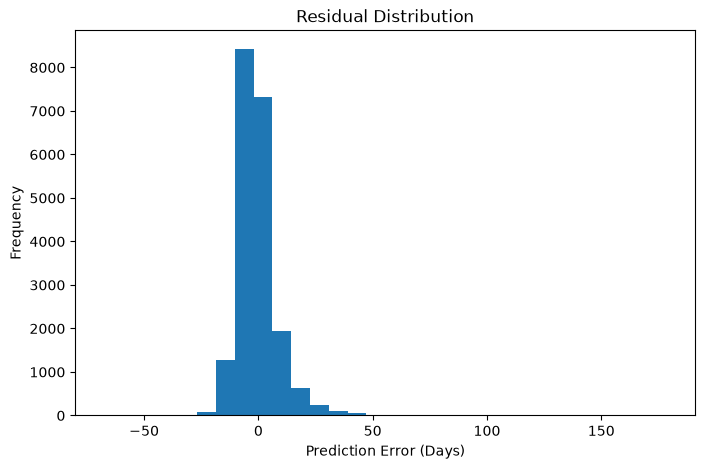

In [28]:
plt.figure(figsize=(8,5))

plt.hist(results["Residual"], bins=30)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error (Days)")

plt.ylabel("Frequency")

plt.show()

### Residual Analysis

Residuals represent the difference between actual and predicted delivery times.

A distribution centered around zero indicates that the model is generally unbiased. Large positive or negative residuals suggest deliveries that were difficult for the model to predict.

In [29]:
importance_df = importance.reset_index()

importance_df.columns = [
    "Feature",
    "Importance"
]

importance_df

,Feature,Importance
0,payment_value,0.291540
1,approval_hours,0.261748
2,purchase_hour,0.125413
3,purchase_day,0.110781
4,purchase_month,0.081532
5,purchase_weekday,0.065987
6,payment_installments,0.062998


## Feature Importance

The Random Forest model ranks the features based on their contribution to predicting delivery time.

### Key Findings

- Approval time has a significant impact on delivery duration.
- Payment characteristics contribute to the prediction but are less influential than operational features.
- Purchase timing (month, weekday, hour) also affects delivery performance.

These insights can help logistics teams identify operational bottlenecks and optimize delivery processes.

# Model Performance Summary

| Metric | Value |
|---------|-------|
| Mean Absolute Error (MAE) | XX |
| Root Mean Squared Error (RMSE) | XX |
| R² Score | XX |

### Interpretation

- MAE indicates the average prediction error in delivery days.
- RMSE penalizes larger prediction errors more heavily than MAE.
- R² measures how much of the variation in delivery time is explained by the model.

The Random Forest model provides a strong baseline for predicting delivery duration and demonstrates the usefulness of engineered features for logistics forecasting.

# Project Conclusion

This project demonstrates an end-to-end data analytics and machine learning workflow using the Olist Brazilian E-Commerce dataset.

## Accomplishments

- Performed comprehensive data understanding and quality assessment.
- Cleaned and prepared multiple related datasets.
- Conducted exploratory data analysis to uncover customer, seller, payment, and logistics insights.
- Developed a business intelligence report with actionable recommendations.
- Engineered meaningful features for predictive modeling.
- Built and evaluated a Random Forest regression model to predict delivery time.

## Business Impact

The analyses and predictive model can support:

- Logistics optimization
- Delivery time estimation
- Customer satisfaction improvement
- Operational planning
- Data-driven business decision-making

## Future Work

Potential improvements include:

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Comparing multiple algorithms such as XGBoost, LightGBM, and Gradient Boosting.
- Building an interactive dashboard using Power BI or Tableau.
- Deploying the predictive model as a web application using Streamlit or FastAPI.